# Buzzer Detection via Cosine Similarity - YouTube Videos
**NLP Models:**   IndoBERTweet and Multilingual E5  
**Confirmatory/Supplementary Formula:** TF-IDF (Term Frequency - Inverse Document Frequency)     
**Dataset:** `analysis_df_videos.csv` (YouTube video comments filtered to between 12 December 2023 to 14 February 2024)

Two similarity signals are computed:
1. **Within-user** — pairwise cosine similarity across each commenter's own comment history (i.e. high mean → templated messaging)
2. **Temporal cross-user** — cosine similarity between comments from *different* users posted within a 5-minute window on the same playlist  (i.e. proximity in time and semantic similarity → coordinated behaviour)

Order of execution:
- First run: cells 0 → 15 in order
- Subsequent runs: skip cells 13–14 (encoding), run cell 15 (load embeddings) instead

## 1. Install dependencies

In [1]:
!pip install sentence_transformers pandas emoji -q


## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import re
import emoji
import html
from itertools import combinations   # create and maniupulate iterators - efficient looping 
from transformers import AutoTokenizer, AutoModel  # from huggingface transformers library
                                                   # AutoTokenizer handles word-splitting, subword-tokenization (like Byte Pair Encoding), and adds special tokens (such as padding or classification tags)
                                                   # AutoModel is a generic model class that can be used to load any pre-trained model architecture (like BERT, GPT, etc.) from the Hugging Face library. 
from sentence_transformers import SentenceTransformer # To compute embeddings of sentences using pre-trained models
from sklearn.feature_extraction.text import TfidfVectorizer # To convert comments into matrix of TF-IDF features


In [4]:
from huggingface_hub import login
import getpass

hf_token = getpass.getpass("Enter HuggingFace token: ")
login(token=hf_token)

## 3. Configuration
Set paths and thresholds here. This section will be edited based on the relevant steps below - rerun if required.

In [53]:
# Paths - VIDEOS
CSV_INPUT_VIDEOS          = "videos_comments_analysis.csv"
OUTPUT_WITHIN_VIDEOS      = "within_user_similarity_videos.csv"
OUTPUT_TEMPORAL_5_VIDEOS  = "temporal_similarity_5min_videos.csv"   


# Thresholds for wihin-user and cross-user temporal similarity detection
WITHIN_THRESHOLD_TWEET      = 0.841   # within-user IndoBERTweet — 95th percentile
WITHIN_THRESHOLD_E5         = 0.915   # within-user E5 — raised; distribution compressed into narrower range
TFIDF_THRESHOLD_WITHIN      = 0.412   # within-user TF-IDF — 95th percentile of left-skewed distribution

TEMPORAL_THRESHOLD_TWEET    = 0.835   # 99th percentile of 5-min distribution
TEMPORAL_THRESHOLD_E5       = 0.901   # 99th percentile of 5-min distribution
TFIDF_THRESHOLD_TEMPORAL    = 0.146   # 99th percentile of 5-min TF-IDF distribution

WINDOW_MINUTES     = 5
MIN_COMMENTS       = 4      # minimum comments per user for both analyses
MIN_WORDS          = 3      # minimum words per comment  

# Runtime 
MAX_LENGTH = 128    # IndoBERTweet max tokens; covers 98.5% of comments, determined from the results of "Token Length Diagnostics" section
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE.upper()}")

Device: CPU


## 4. Text Preprocessing

Three separate functions — one per model and one for TF-IDF — each optimised for its own purpose.

| Step | IndoBERTweet | Multilingual E5 | TF-IDF |
|---|---|---|---|
| Lowercase | ✅ `uncased` model | ❌ XLM-RoBERTa is *cased* | ✅ |
| `@mention` → `@USER` | ✅ Learned token | ❌ Strip | ❌ Strip |
| URL → `HTTPURL` | ✅ Learned token | ❌ Strip | ❌ Strip |
| Emoji → text | ✅ | ✅ | ❌ Strip |
| Stopword removal | ❌ | ❌ | ✅ |
| Punctuation removal | ❌ | ❌ | ✅ |

In [6]:
# This ensures that the comments will be processed to a format that is tailored to both models' and the TF-IDF function's requirements.

# For IndoBERTtweet 
def preprocess_for_indobertweet(text):
    text = str(text).lower()                                                    # uncased model
    text = re.sub(r'http\S+|www\.\S+', 'HTTPURL', text)                         # URL → learned token
    text = re.sub(r'@\w+', '@USER', text)                                       # mention → learned token
    text = emoji.demojize(text, delimiters=(" ", " "))                          # emoji → text
    text = text.replace("<br>", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)                                  # squash spam
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# For Multilingual E5 (base model)
def preprocess_for_e5(text):
    text = str(text)                                                            # preserve casing
    text = re.sub(r'http\S+|www\.\S+', '', text)                                # strip URLs entirely
    text = re.sub(r'@\w+', '', text)                                            # strip mentions entirely
    text = emoji.demojize(text, delimiters=(" ", " "))                          # emoji → text
    text = text.replace("<br>", " ").replace("\n", " ").replace("\t", " ")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)                                  # squash spam
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# For TF-IDF
# stopword list for TF-IDF since sklearn's TfidfVectorizer does not have a built-in Indonesian stopword list
# stopword list is simple, based on function words, informal particles, and address terms commonly used in Indonesian social media comments
STOPWORDS_TFIDF = {
    # Function words
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "dengan", "untuk",
    "pada", "adalah", "dalam", "tidak", "atau", "juga", "sudah", "akan",
    "ada", "kita", "kami", "mereka", "saya", "aku", "kamu", "dia",
    # Informal particles
    "sih", "deh", "nih", "dong", "loh", "yg", "ny", "nya", "aja",
    "gak", "ga", "nggak", "udah", "udh", "jg",
    # Address terms
    "kak", "mas", "pak", "bu", "bang", "bro", "sis"
}

def preprocess_for_tfidf(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)        # strip URLs
    text = re.sub(r'@\w+', '', text)                    # strip mentions
    text = re.sub(r'[^\w\s]', '', text)                 # strip punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in STOPWORDS_TFIDF]
    return ' '.join(words)




## 5. IndoBERTweet Embedding Generator
Mean-pooling over token embeddings, then L2-normalised. IndoBERTweet is a masked language model trained exclusively to predict missing words, hence mean-pooling is necessary to create sentence (i.e. "whole comment") embeddings. Multilingual E5 model does not require this step. 

In [ ]:
def get_indobertweet_embeddings(texts, model, tokenizer, device):
    encoded = tokenizer(
        texts, padding=True, truncation=True, max_length=256, return_tensors='pt'    # may want to increase max_length since YouTube comments can be longer than tweets, but this is a starting point
    ).to(device)
    with torch.no_grad():
        output = model(**encoded)
    token_embeddings = output[0]                       # full matrix of per-token embeddings before any pooling
    input_mask_expanded = (
        encoded['attention_mask'].unsqueeze(-1).expand(token_embeddings.size()).float()
    )
    pooled = torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(       # mean
        input_mask_expanded.sum(1), min=1e-9
    )
    return F.normalize(pooled, p=2, dim=1)             # normalises each embedding to unit length

## 6. Encode All Comments — Single Pass

In [8]:
def encode_all_comments(df, tweet_model, tweet_tokenizer, e5_model, device, batch_size=32):
    tweet_texts = df['clean_indobertweet'].tolist()
    e5_texts    = df['clean_e5'].tolist()
    all_tweet, all_e5 = [], []

    for i in range(0, len(tweet_texts), batch_size):
        
        # IndoBERTweet — its own preprocessed column
        batch_tweet = tweet_texts[i:i + batch_size]
        tweet_emb = get_indobertweet_embeddings(batch_tweet, tweet_model, tweet_tokenizer, device)
        all_tweet.append(tweet_emb.cpu())

        # Multilingual E5 — its own preprocessed column + query prefix + l2-normalisation
        batch_e5 = [f"query: {t}" for t in e5_texts[i:i + batch_size]]          # query: prefix is E5's required instruction format for semantic similarity tasks
        e5_emb = e5_model.encode(
            batch_e5, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False
        )
        all_e5.append(e5_emb.cpu())

        if (i // batch_size + 1) % 10 == 0:
            print(f"  Encoded {min(i + batch_size, len(tweet_texts))}/{len(tweet_texts)} comments...")

    return torch.cat(all_tweet, dim=0), torch.cat(all_e5, dim=0)

## 7. Within-User Similarity

For each `author_anon` with ≥ 2 comments, compute **all pairwise cosine similarities** across their own comments using `combinations()`. Aggregated to `mean_sim` and `max_sim` per user.

| Score | Interpretation |
|---|---|
| `mean_sim` high | Near-identical templated messages → strong buzzer signal |
| `max_sim` high but `mean_sim` low | Occasional repetition, hence less suspicious |

In [9]:
# Threshold for mean within-user cosine similarity detection (Step 3) 
# WITHIN_THRESHOLD_TWEET = 0.85  
# WITHIN_THRESHOLD_E5    = 0.92
# TFIDF_THRESHOLD_WITHIN   = 0.40

def compute_within_user_similarity(df, tweet_embs, e5_embs, tfidf_matrix):
    records = []

    for author_anon, grp in df.groupby("author_anon"):
        idx = grp.index.tolist()
        if len(idx) < 2:
            continue

        t = tweet_embs[idx]   # (n_comments, hidden_dim)
        e = e5_embs[idx]
        tfidf_sub = tfidf_matrix[idx]         # sparse submatrix for this user

        tweet_sims, e5_sims, tfidf_sims = [], [], []
        for a, b in combinations(range(len(idx)), 2):           # to generate every unique pair without repetition
            tweet_sims.append(torch.dot(t[a], t[b]).item())
            e5_sims.append(torch.dot(e[a], e[b]).item())
            tfidf_sims.append(
                float((tfidf_sub[a] * tfidf_sub[b].T).toarray()[0, 0])
            )

        records.append({
            "author_anon":           author_anon,
            "n_comments":            len(idx),
            "mean_sim_indobertweet": round(float(np.mean(tweet_sims)), 4),
            "max_sim_indobertweet":  round(float(np.max(tweet_sims)), 4),
            "mean_sim_e5":           round(float(np.mean(e5_sims)), 4),
            "max_sim_e5":            round(float(np.max(e5_sims)), 4),
            "mean_sim_tfidf":        round(float(np.mean(tfidf_sims)), 4),
            "max_sim_tfidf":         round(float(np.max(tfidf_sims)), 4),
        })

    return pd.DataFrame(records)

## 8. Temporal-Proximity Cross-User Similarity

Group by `playlist_id` - videos showing the same edition of presidential debate livestreams are featured in the same playlist, so potential coordination tactics by the buzzers targeting the same event can be captured. Within each playlist, comments are sorted by `published_at` and every cross-user pair within `window_minutes` is scored.

Both `video_id_a` and `video_id_b` are stored per pair — where they differ, the pair is a genuine cross-video (but likely to be within the same playlist) match, which is the coordination pattern that buzzers could exhibit.

Run this function with `window_minutes=5`.

In [25]:
# Threshold for cross-user temporal pair cosine similarity detection (from Step 3)
# TEMPORAL_THRESHOLD = 0.97
# TFIDF_THRESHOLD_TEMPORAL = 0.70    

def compute_temporal_similarity(df, tweet_embs, e5_embs, tfidf_matrix, window_minutes=5):
    records = []

    for playlist_id, grp in df.groupby("playlist_id"):
        grp = grp.sort_values("published_at")
        rows = list(grp.itertuples())
        n = len(rows)

        for ii in range(n):

            for jj in range(ii + 1, n):
                delta = (
                    rows[jj].published_at - rows[ii].published_at
                ).total_seconds() / 60

                if delta > window_minutes:
                    break

                if rows[ii].author_anon == rows[jj].author_anon:
                    continue

                sim_tweet = torch.dot(tweet_embs[rows[ii].Index], tweet_embs[rows[jj].Index]).item()
                sim_e5    = torch.dot(e5_embs[rows[ii].Index],    e5_embs[rows[jj].Index]).item()

                sim_tfidf = float(
                    (tfidf_matrix[rows[ii].Index] * tfidf_matrix[rows[jj].Index].T).toarray()[0, 0]
                )

                records.append({
                    "playlist_id":      playlist_id,
                    "video_id_a":       rows[ii].video_id,    # from the row itself
                    "video_id_b":       rows[jj].video_id,    # may differ — cross-video pair
                    "user_a":           rows[ii].author_anon,
                    "user_b":           rows[jj].author_anon,
                    "time_delta_min":   round(delta, 2),
                    "sim_indobertweet": round(sim_tweet, 4),
                    "sim_e5":           round(sim_e5, 4),
                    "sim_tfidf":        round(sim_tfidf, 4),
                    "text_a":           rows[ii].comment,
                    "text_b":           rows[jj].comment,
                })

    return pd.DataFrame(records)


## 9. Load Data, Filter by Word Count and Preprocessing + TF-IDF Vectorisation

In [12]:
# Load video data
df = pd.read_csv(CSV_INPUT_VIDEOS)
df["published_at"] = pd.to_datetime(df["published_at"], format='mixed', dayfirst=False, utc=True)
df = df[["author_anon", "comment", "published_at", "video_id", "playlist_id"]].dropna(subset=["comment"])
df = df.reset_index(drop=True)   # Align row position with embedding tensor index

Mean   : 16.1 words
Median : 10.0 words
10th % : 2.0 words
25th % : 5.0 words

Comments with < 3 words : 16,577 (10.6%)
Comments with < 5 words : 35,515 (22.6%)
Comments with < 8 words : 60,475 (38.6%)


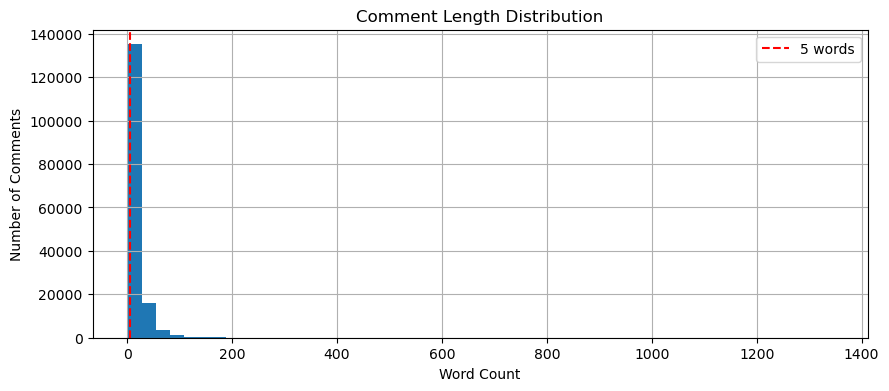

['\u200b@nawangnurcahyoo ok',
 'Amin',
 'FIX #PRABOWOGIBRAN🔥🔥🔥',
 '😅',
 '1',
 'Aniesss munafik.',
 'Anis ❤❤❤',
 'Gibran ❤',
 'amim terbaik',
 'tetep 02',
 'gibran helloss🤘🏻',
 'afk 😂',
 'Prabowo !',
 'rameee, seru!',
 'Napsu dia',
 'AMIN 1',
 'bismillah, AMIN',
 '😂',
 'Wkwkkwkw😂😂😂',
 '\u200b@Sahudi123-hy5lccieeeee bazzer']

In [13]:
# Display comment length distribution
# Distribution is used to inform the decision regarding the minimum word count in a comment to be considered for similarity detection.
# Ensure that that the threshold will not substantially reduce the number of comments for analysis in the dataset. 

word_counts = df["comment"].str.split().str.len()

print(f"Mean   : {word_counts.mean():.1f} words")
print(f"Median : {word_counts.median():.1f} words")
print(f"10th % : {word_counts.quantile(0.10):.1f} words")
print(f"25th % : {word_counts.quantile(0.25):.1f} words")
print(f"")
print(f"Comments with < 3 words : {(word_counts < 3).sum():,} ({(word_counts < 3).mean()*100:.1f}%)")
print(f"Comments with < 5 words : {(word_counts < 5).sum():,} ({(word_counts < 5).mean()*100:.1f}%)")
print(f"Comments with < 8 words : {(word_counts < 8).sum():,} ({(word_counts < 8).mean()*100:.1f}%)")

word_counts.hist(bins=50, figsize=(10, 4))
plt.xlabel("Word Count")
plt.ylabel("Number of Comments")
plt.title("Comment Length Distribution")
plt.axvline(5, color="red", linestyle="--", label="5 words")
plt.legend()
plt.show()

# Chose to filter comments with less than 3 words since they only took up 10.6% of the data - ensure that we are not losing too much information by filtering them out
# Check a sample of comments with fewer than 3 words - ensure that these comments are truely uninformative, and that filtering them out is appropriate.
df[df["comment"].str.split().str.len() < 3]["comment"].sample(20).tolist()

# Update MIN_WORDS to 3 in the configuration step (Step 3)

In [14]:
# Apply word count filter (i.e. the comment should have at least 3 words)
df["word_count"] = df["comment"].str.split().str.len()
df = df[df["word_count"] >= MIN_WORDS].reset_index(drop=True)

# Double check the number of comments in the filtered dataset is lesser than the original dataset
print(f"Comments : {len(df):,}  (≥ {MIN_WORDS} words)")
print(f"Users    : {df['author_anon'].nunique():,}")
print(f"Videos   : {df['video_id'].nunique():,}")
df.head(3)

# Model-specific preprocessing
df["clean_indobertweet"] = df["comment"].apply(preprocess_for_indobertweet)
df["clean_e5"]           = df["comment"].apply(preprocess_for_e5)

# TF-IDF preprocessing
df["clean_tfidf"]  = df["comment"].apply(preprocess_for_tfidf)
tfidf_vectorizer   = TfidfVectorizer()
tfidf_matrix       = tfidf_vectorizer.fit_transform(df["clean_tfidf"])
print(f"TF-IDF matrix      : {tfidf_matrix.shape}")


Comments : 140,264  (≥ 3 words)
Users    : 72,197
Videos   : 77
TF-IDF matrix      : (140264, 105556)


## 10. Token Length Diagnostics - IndoBERTweet
Run before loading models. Check truncation rows and update `MAX_LENGTH` in Configuration (Step 3) if needed — use the **95th percentile** as decision threshold.


In [ ]:
id_diag_tokenizer = AutoTokenizer.from_pretrained("indolem/indobertweet-base-uncased")

lengths = df["clean_indobertweet"].apply(
    lambda t: len(id_diag_tokenizer.encode(t, add_special_tokens=True))
)

print(f"Mean   : {lengths.mean():.1f} tokens")
print(f"Median : {lengths.median():.1f} tokens")
print(f"95th % : {lengths.quantile(0.95):.1f} tokens")
print(f"99th % : {lengths.quantile(0.99):.1f} tokens")
print(f"Max    : {lengths.max()} tokens")
print(f"Truncated at 128 : {(lengths > 128).sum():,} comments ({(lengths > 128).mean()*100:.1f}%)")
print(f"Truncated at 256 : {(lengths > 256).sum():,} comments ({(lengths > 256).mean()*100:.1f}%)")

## Since max_length of 128 tokens will cover 98.5% of the comments, we will set the max_length to 128 for IndoBERTweet embeddings.

Mean   : 28.9 tokens
Median : 20.0 tokens
95th % : 77.0 tokens
99th % : 153.0 tokens
Max    : 1902 tokens
Truncated at 128 : 2,094 comments (1.5%)
Truncated at 256 : 431 comments (0.3%)


## 11. Token Length Diagnostics - Multilingual E5
E5 uses XLM-RoBERTa's multilingual vocabulary — the same comment can produce more subword tokens than IndoBERTweet. Default `max_seq_length` is 512. Update in the subsequent step (i.e. Step 12 - Load Model) if needed.

In [22]:

e5_diag_tokenizer = AutoTokenizer.from_pretrained("intfloat/multilingual-e5-base")

e5_lengths = df["clean_e5"].apply(
    lambda t: len(e5_diag_tokenizer.encode(t, add_special_tokens=True))
)

print(f"Mean       : {e5_lengths.mean():.1f} tokens")
print(f"Median     : {e5_lengths.median():.1f} tokens")
print(f"95th %   : {e5_lengths.quantile(0.95):.1f} tokens")
print(f"99th %   : {e5_lengths.quantile(0.99):.1f} tokens")
print(f"Max        : {e5_lengths.max()} tokens")
print(f"")
print(f"Truncated at 256 : {(e5_lengths > 256).sum():,} comments ({(e5_lengths > 256).mean()*100:.1f}%)")
print(f"Truncated at 512 : {(e5_lengths > 512).sum():,} comments ({(e5_lengths > 512).mean()*100:.1f}%)")
print(f"")
print(f"Current e5_model.max_seq_length = 512 (default)")

## Since max_length of 512 token (default) covers 99.9% of comments, we will set the max_length to 512 (default) for Multilingual E5 embeddings.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1531 > 512). Running this sequence through the model will result in indexing errors


Mean       : 35.2 tokens
Median     : 24.0 tokens
95th %   : 94.0 tokens
99th %   : 190.0 tokens
Max        : 2747 tokens

Truncated at 256 : 667 comments (0.5%)
Truncated at 512 : 163 comments (0.1%)

Current e5_model.max_seq_length = 512 (default)


## 12. Load Models

In [133]:
print("Loading IndoBERTweet...")
tweet_tokenizer = AutoTokenizer.from_pretrained("indolem/indobertweet-base-uncased")
tweet_model     = AutoModel.from_pretrained("indolem/indobertweet-base-uncased").to(DEVICE)
tweet_model.eval()

print("Loading Multilingual E5...")
e5_model = SentenceTransformer("intfloat/multilingual-e5-base", device=DEVICE)
e5_model.max_seq_length = 512   # default - determined to be enough based on results from Token Length Diagnostics

print("Done.")

Loading IndoBERTweet...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading Multilingual E5...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Done.


## 13. Encode All Comments
Step with high computational cost - run once, then save embeddings via Step 14 and load via Step 15 in future sessions.

In [134]:
print(f"Encoding {len(df):,} comments...")
tweet_embs, e5_embs = encode_all_comments(
    df, tweet_model, tweet_tokenizer, e5_model, DEVICE, BATCH_SIZE
)
print(f"IndoBERTweet tensor : {tweet_embs.shape}")
print(f"E5 tensor           : {e5_embs.shape}")

Encoding 140,264 comments...
  Encoded 320/140264 comments...
  Encoded 640/140264 comments...
  Encoded 960/140264 comments...
  Encoded 1280/140264 comments...
  Encoded 1600/140264 comments...
  Encoded 1920/140264 comments...
  Encoded 2240/140264 comments...
  Encoded 2560/140264 comments...
  Encoded 2880/140264 comments...
  Encoded 3200/140264 comments...
  Encoded 3520/140264 comments...
  Encoded 3840/140264 comments...
  Encoded 4160/140264 comments...
  Encoded 4480/140264 comments...
  Encoded 4800/140264 comments...
  Encoded 5120/140264 comments...
  Encoded 5440/140264 comments...
  Encoded 5760/140264 comments...
  Encoded 6080/140264 comments...
  Encoded 6400/140264 comments...
  Encoded 6720/140264 comments...
  Encoded 7040/140264 comments...
  Encoded 7360/140264 comments...
  Encoded 7680/140264 comments...
  Encoded 8000/140264 comments...
  Encoded 8320/140264 comments...
  Encoded 8640/140264 comments...
  Encoded 8960/140264 comments...
  Encoded 9280/140264 

## 14. Save embeddings to disk

In [135]:
torch.save(tweet_embs, "tweet_embs.pt")
torch.save(e5_embs, "e5_embs.pt")
print("Embeddings saved to tweet_embs.pt and e5_embs.pt")

Embeddings saved to tweet_embs.pt and e5_embs.pt


## 15. Load embeddings from disk

In [15]:
tweet_embs = torch.load("tweet_embs.pt", weights_only=True)
e5_embs    = torch.load("e5_embs.pt", weights_only=True)
print(f"IndoBERTweet tensor : {tweet_embs.shape}")
print(f"E5 tensor           : {e5_embs.shape}")

IndoBERTweet tensor : torch.Size([140264, 768])
E5 tensor           : torch.Size([140264, 768])


## 16. Compute Within-User Similarity (Videos)

In [18]:
print("Computing within-user similarity...")
within_df = compute_within_user_similarity(df, tweet_embs, e5_embs, tfidf_matrix)

# Filter out users with less than 4 comments (MIN_COMMENTS threshold set in Step 3)
within_df = within_df[within_df["n_comments"] >= MIN_COMMENTS].reset_index(drop=True)

# Flag by IndoBERTweet and E5 model agreement
within_df["flagged_by"] = "unflagged"

within_df.loc[
    (within_df["mean_sim_indobertweet"] >= WITHIN_THRESHOLD_TWEET) &
    (within_df["mean_sim_e5"]           >= WITHIN_THRESHOLD_E5),
    "flagged_by"
] = "both"

within_df.loc[
    (within_df["mean_sim_indobertweet"] >= WITHIN_THRESHOLD_TWEET) &
    (within_df["mean_sim_e5"]           <  WITHIN_THRESHOLD_E5),
    "flagged_by"
] = "indobertweet_only"

within_df.loc[
    (within_df["mean_sim_indobertweet"] <  WITHIN_THRESHOLD_TWEET) &
    (within_df["mean_sim_e5"]           >= WITHIN_THRESHOLD_E5),
    "flagged_by"
] = "e5_only"

within_df["tfidf_flag"] = within_df["mean_sim_tfidf"] >= TFIDF_THRESHOLD_WITHIN

within_df.to_csv(OUTPUT_WITHIN_VIDEOS, index=False)

print(f"Users scored        : {len(within_df):,}  (≥ {MIN_COMMENTS} comments)")
print(f"Flagged by both     : {(within_df['flagged_by'] == 'both').sum():,}")
print(f"Flagged by IndoBERT only : {(within_df['flagged_by'] == 'indobertweet_only').sum():,}")
print(f"Flagged by E5 only       : {(within_df['flagged_by'] == 'e5_only').sum():,}")
print(f"TF-IDF flagged      : {within_df['tfidf_flag'].sum():,}")
print(f"Output saved        : {OUTPUT_WITHIN_VIDEOS}")
within_df.head(10)

Computing within-user similarity...
Users scored        : 5,955  (≥ 4 comments)
Flagged by both     : 195
Flagged by IndoBERT only : 73
Flagged by E5 only       : 73
TF-IDF flagged      : 316
Output saved        : within_user_similarity_videos.csv


,author_anon,n_comments,mean_sim_indobertweet,max_sim_indobertweet,mean_sim_e5,max_sim_e5,mean_sim_tfidf,max_sim_tfidf,flagged_by,tfidf_flag
0,User_1000,5,0.7964,0.8753,0.8846,0.9371,0.0896,0.1944,unflagged,False
1,User_10014,5,0.4231,0.5526,0.8047,0.8562,0.0000,0.0000,unflagged,False
2,User_1002,8,0.7199,0.8293,0.8664,0.9236,0.0495,0.2156,unflagged,False
3,User_10021,8,0.6294,0.8738,0.8349,0.9431,0.0182,0.2388,unflagged,False
4,User_10022,4,0.7405,0.8417,0.8845,0.9211,0.0788,0.2210,unflagged,False
5,User_10025,7,0.4554,0.6152,0.8123,0.8871,0.0023,0.0493,unflagged,False
6,User_10039,27,0.6446,0.8927,0.8368,0.9430,0.0317,0.8510,unflagged,False
7,User_10045,5,0.5677,0.6805,0.8185,0.8541,0.0044,0.0441,unflagged,False
8,User_1006,10,0.5632,0.7506,0.8747,0.9295,0.1035,0.4795,unflagged,False
9,User_10066,4,0.6769,0.8272,0.8428,0.8799,0.1059,0.3439,unflagged,False


## 17. Compute Temporal Cross-User Similarity — 5-Minute Window (Videos)

In [ ]:
# ── Pre-filter to eligible users (≥ MIN_COMMENTS) before temporal computation ─
user_counts    = df.groupby("author_anon").size()
eligible_users = user_counts[user_counts >= MIN_COMMENTS].index
df_temporal    = df[df["author_anon"].isin(eligible_users)]   # no reset_index — preserves original indices

print(f"Eligible users   : {df_temporal['author_anon'].nunique():,}  (≥ {MIN_COMMENTS} comments)")
print(f"Comments in pool : {len(df_temporal):,}")

# ── Compute temporal similarity ───────────────────────────────────────────────
print(f"\nComputing temporal similarity ({WINDOW_MINUTES} min)...")
temporal_5 = compute_temporal_similarity(
    df_temporal, tweet_embs, e5_embs, tfidf_matrix, window_minutes=WINDOW_MINUTES
)


In [ ]:

# ── Flag by model agreement ───────────────────────────────────────────────────
temporal_5["flagged_by"] = "unflagged"
temporal_5.loc[
    (temporal_5["sim_indobertweet"] >= TEMPORAL_THRESHOLD_TWEET) &
    (temporal_5["sim_e5"]           >= TEMPORAL_THRESHOLD_E5),
    "flagged_by"
] = "both"
temporal_5.loc[
    (temporal_5["sim_indobertweet"] >= TEMPORAL_THRESHOLD_TWEET) &
    (temporal_5["sim_e5"]           <  TEMPORAL_THRESHOLD_E5),
    "flagged_by"
] = "indobertweet_only"
temporal_5.loc[
    (temporal_5["sim_indobertweet"] <  TEMPORAL_THRESHOLD_TWEET) &
    (temporal_5["sim_e5"]           >= TEMPORAL_THRESHOLD_E5),
    "flagged_by"
] = "e5_only"

temporal_5["tfidf_flag"] = temporal_5["sim_tfidf"] >= TFIDF_THRESHOLD_TEMPORAL

temporal_5.to_csv(OUTPUT_TEMPORAL_5_VIDEOS, index=False)

flagged_t5 = temporal_5[temporal_5["flagged_by"] != "unflagged"]

print(f"Pairs scored             : {len(temporal_5):,}")
print(f"Flagged by both          : {(temporal_5['flagged_by'] == 'both').sum():,}")
print(f"Flagged by IndoBERT only : {(temporal_5['flagged_by'] == 'indobertweet_only').sum():,}")
print(f"Flagged by E5 only       : {(temporal_5['flagged_by'] == 'e5_only').sum():,}")
print(f"TF-IDF flagged           : {temporal_5['tfidf_flag'].sum():,}")
print(f"Output saved             : {OUTPUT_TEMPORAL_5_VIDEOS}")
temporal_5.head(10)

In [57]:
print(temporal_5["sim_indobertweet"].describe())
print(temporal_5["sim_e5"].describe())
print(temporal_5["sim_tfidf"].describe())

## Results indicate that the threshold need to be higher than 0.80 for temporal threshold --> increase to 0.95 (this will help to mitigate the common stimulus problem of watching the same debate)

count    2.010354e+06
mean     5.668548e-01
std      1.078178e-01
min      2.420000e-02
25%      4.882000e-01
50%      5.628000e-01
75%      6.400000e-01
max      1.000000e+00
Name: sim_indobertweet, dtype: float64
count    2.010354e+06
mean     8.241524e-01
std      2.964253e-02
min      6.594000e-01
25%      8.039000e-01
50%      8.230000e-01
75%      8.432000e-01
max      1.000000e+00
Name: sim_e5, dtype: float64
count    2.010354e+06
mean     1.054139e-02
std      3.152435e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: sim_tfidf, dtype: float64


## 18. Triangulate Buzzer Suspects (Videos)
Accounts appearing in **both** flagged sets are primary suspects. Pool A alone forms the secondary suspect list — all accounts showing template repetition regardless of temporal coordination.

In [58]:
# ── Pool A: Within-user neural + TF-IDF ──────────────────────────────────────
pool_a = set(
    within_df[
        (within_df["flagged_by"] != "unflagged") &
        (within_df["tfidf_flag"] == True)
    ]["author_anon"]
)

# ── Pool B: Temporal neural + TF-IDF ─────────────────────────────────────────
flagged_t5_strict = flagged_t5[flagged_t5["tfidf_flag"] == True]
pool_b             = set(flagged_t5_strict["user_a"]) | set(flagged_t5_strict["user_b"])

# ── Primary suspects: both signals confirmed ──────────────────────────────────
primary_suspects   = pool_a & pool_b

# ── Secondary suspects: template repetition only (superset of primary) ────────
secondary_suspects = pool_a

print("=" * 55)
print(f"  Pool A (within-user neural + TF-IDF)  : {len(pool_a):>6,}")
print(f"  Pool B (temporal neural + TF-IDF)     : {len(pool_b):>6,}")
print("-" * 55)
print(f"  Primary   (pool A ∩ pool B)            : {len(primary_suspects):>6,}  (strongest)")
print(f"  Secondary (pool A)                     : {len(secondary_suspects):>6,}  (template repeaters)")
print("=" * 55)

  Pool A (within-user neural + TF-IDF)  :    241
  Pool B (temporal neural + TF-IDF)     :  1,283
-------------------------------------------------------
  Primary   (pool A ∩ pool B)            :     36  (strongest)
  Secondary (pool A)                     :    241  (template repeaters)


In [59]:
# Save the primary and secondary suspect lists to CSV files for further analysis or reporting

# Primary suspect profiles + comments combined 
primary_combined = df[df["author_anon"].isin(primary_suspects)][
    ["author_anon", "comment", "published_at", "video_id", "playlist_id"]
].merge(
    within_df[["author_anon", "n_comments", "mean_sim_indobertweet", "max_sim_indobertweet",
               "mean_sim_e5", "max_sim_e5", "mean_sim_tfidf", "max_sim_tfidf", "flagged_by", "tfidf_flag"]],
    on="author_anon", how="left"
).sort_values(["mean_sim_indobertweet", "author_anon", "published_at"], ascending=[False, True, True])

primary_combined.to_csv("primary_suspects_videos.csv", index=False)
print(f"Primary suspects   : {len(primary_suspects):,} users | {len(primary_combined):,} comments")
print(f"Saved              : primary_suspects_videos.csv")

# Secondary suspect profiles + comments combined 
secondary_combined = df[df["author_anon"].isin(secondary_suspects)][
    ["author_anon", "comment", "published_at", "video_id", "playlist_id"]
].merge(
    within_df[["author_anon", "n_comments", "mean_sim_indobertweet", "max_sim_indobertweet",
               "mean_sim_e5", "max_sim_e5", "mean_sim_tfidf", "max_sim_tfidf", "flagged_by", "tfidf_flag"]],
    on="author_anon", how="left"
).sort_values(["mean_sim_indobertweet", "author_anon", "published_at"], ascending=[False, True, True])

secondary_combined.to_csv("secondary_suspects_videos.csv", index=False)
print(f"Secondary suspects : {len(secondary_suspects):,} users | {len(secondary_combined):,} comments")
print(f"Saved              : secondary_suspects_videos.csv")


Primary suspects   : 36 users | 348 comments
Saved              : primary_suspects_videos.csv
Secondary suspects : 241 users | 2,007 comments
Saved              : secondary_suspects_videos.csv


# APPENDIX

## **Threshold Calibration** (for Step 3)

Three steps to validate and refine `WITHIN_THRESHOLD`, `TEMPORAL_THRESHOLD`, and `TFIDF_THRESHOLD` set in Cell 3.

**Step 1** — plot distributions for all three models to check for bimodality.  
**Step 2** — use percentiles as a data-driven starting point; 99th percentile flags genuine outliers. Note TF-IDF scores are naturally much lower than neural scores — even the 95th percentile may sit below 0.30.  
**Step 3** — manually inspect flagged pairs to confirm they look like coordinated behaviour.

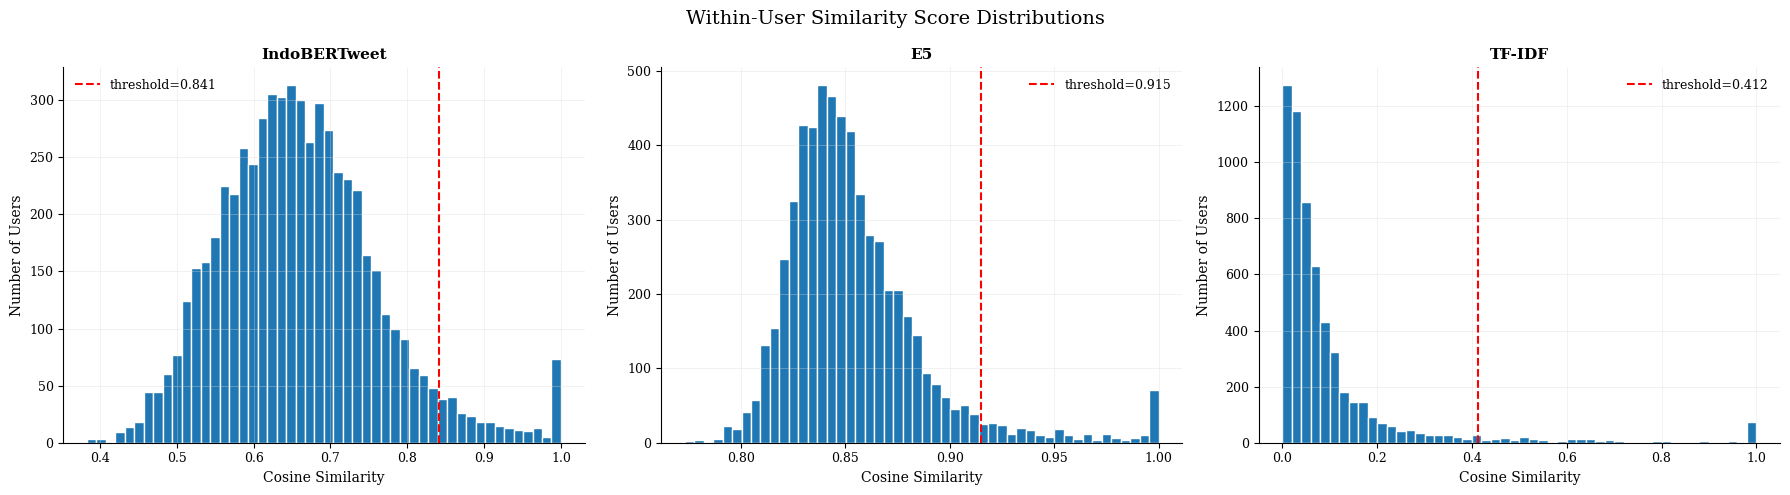

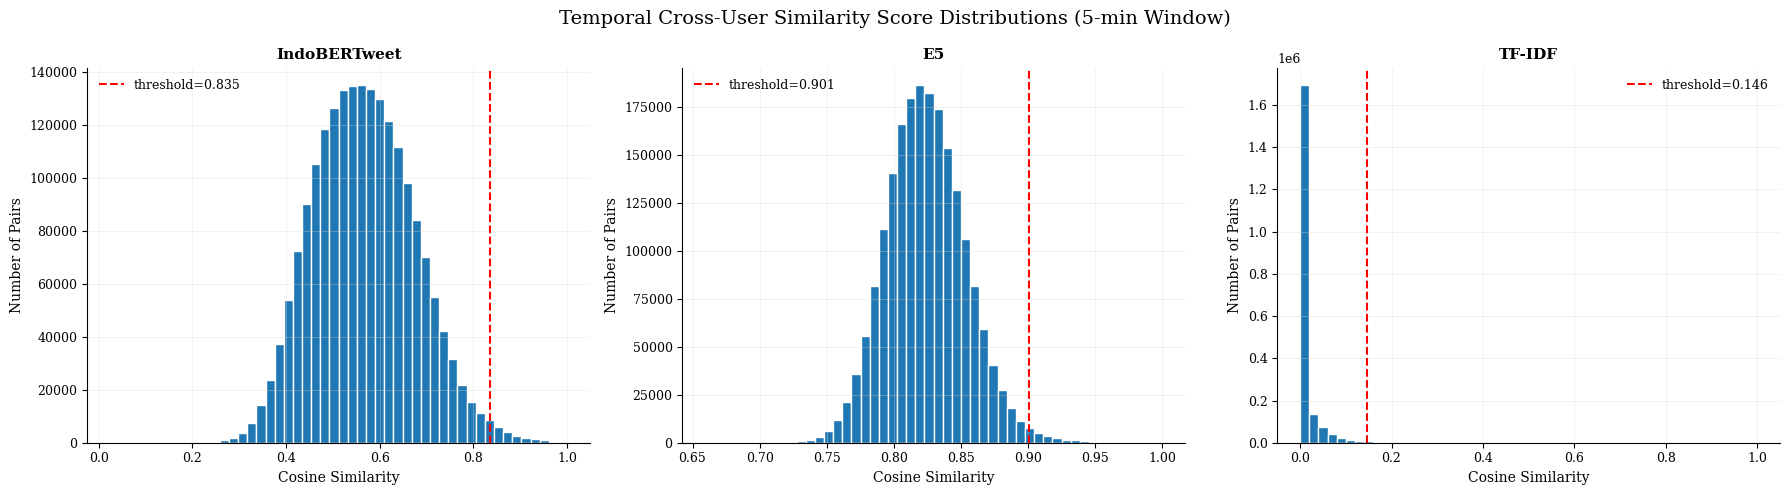

In [63]:
# Step 1: Distribution plots — Within-User and Temporal separated into two figures

# ── Figure 1: Within-User Similarity Distributions ───────────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("Within-User Similarity Score Distributions", fontsize=14)

for ax, col, title, thresh in [
    (axes1[0], "mean_sim_indobertweet", "IndoBERTweet", WITHIN_THRESHOLD_TWEET),
    (axes1[1], "mean_sim_e5",           "E5",           WITHIN_THRESHOLD_E5),
    (axes1[2], "mean_sim_tfidf",        "TF-IDF",       TFIDF_THRESHOLD_WITHIN),
]:
    ax.hist(within_df[col], bins=50, edgecolor="white")
    ax.axvline(thresh, color="red", linestyle="--", label=f"threshold={thresh}")
    ax.set(title=title, xlabel="Cosine Similarity", ylabel="Number of Users")
    ax.legend()

plt.tight_layout()
plt.savefig("similarity_distributions_within_user.png", dpi=150)
plt.show()

# ── Figure 2: Temporal Cross-User Similarity Distributions ───────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("Temporal Cross-User Similarity Score Distributions (5-min Window)", fontsize=14)

for ax, col, title, thresh in [
    (axes2[0], "sim_indobertweet", "IndoBERTweet", TEMPORAL_THRESHOLD_TWEET),
    (axes2[1], "sim_e5",           "E5",           TEMPORAL_THRESHOLD_E5),
    (axes2[2], "sim_tfidf",        "TF-IDF",       TFIDF_THRESHOLD_TEMPORAL),
]:
    ax.hist(temporal_5[col], bins=50, edgecolor="white")
    ax.axvline(thresh, color="red", linestyle="--", label=f"threshold={thresh}")
    ax.set(title=title, xlabel="Cosine Similarity", ylabel="Number of Pairs")
    ax.legend()

plt.tight_layout()
plt.savefig("similarity_distributions_temporal.png", dpi=150)
plt.show()

## LaTeX compatible plots for capstone

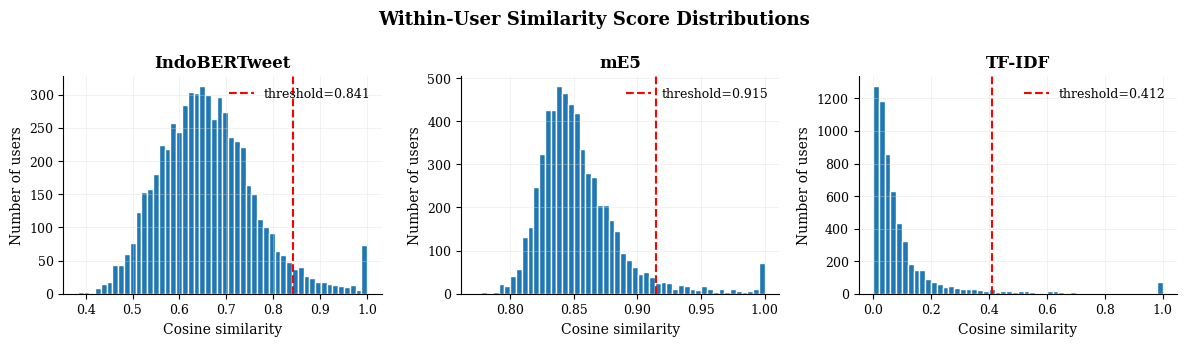

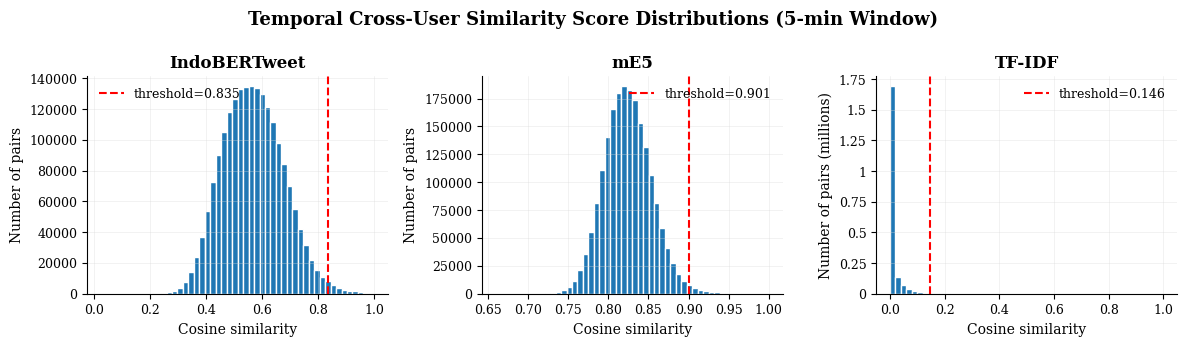

In [72]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl

# ── LaTeX-compatible font settings (serif, matches dissertation body text) ──
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})

# ── Figure 1: Within-User Similarity Distributions ───────────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(12, 3.5))
fig1.suptitle("Within-User Similarity Score Distributions", fontsize=13, fontweight="bold")

for ax, col, title, thresh in [
    (axes1[0], "mean_sim_indobertweet", "IndoBERTweet", WITHIN_THRESHOLD_TWEET),
    (axes1[1], "mean_sim_e5",           "mE5",           WITHIN_THRESHOLD_E5),
    (axes1[2], "mean_sim_tfidf",        "TF-IDF",       TFIDF_THRESHOLD_WITHIN),
]:
    ax.hist(within_df[col], bins=50, edgecolor="white")
    ax.axvline(thresh, color="red", linestyle="--", label=f"threshold={thresh:.3f}")
    ax.set(title=title, xlabel="Cosine similarity", ylabel="Number of users")
    ax.legend(framealpha=0.85, facecolor="white", edgecolor="none")

plt.tight_layout()
plt.savefig("similarity_distributions_within_user.pdf", bbox_inches="tight")
plt.show()

# ── Figure 2: Temporal Cross-User Similarity Distributions ───────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 3.5))
fig2.suptitle("Temporal Cross-User Similarity Score Distributions (5-min Window)", fontsize=13, fontweight="bold")

for ax, col, title, thresh in [
    (axes2[0], "sim_indobertweet", "IndoBERTweet", TEMPORAL_THRESHOLD_TWEET),
    (axes2[1], "sim_e5",           "mE5",           TEMPORAL_THRESHOLD_E5),
    (axes2[2], "sim_tfidf",        "TF-IDF",       TFIDF_THRESHOLD_TEMPORAL),
]:
    ax.hist(temporal_5[col], bins=50, edgecolor="white")
    ax.axvline(thresh, color="red", linestyle="--", label=f"threshold={thresh:.3f}")
    ax.legend(framealpha=0.85, facecolor="white", edgecolor="none")

    if title == "TF-IDF":
        # Scale y-axis ticks to millions and relabel accordingly
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:g}"))
        ax.set(title=title, xlabel="Cosine similarity", ylabel="Number of pairs (millions)")
    else:
        ax.set(title=title, xlabel="Cosine similarity", ylabel="Number of pairs")

plt.tight_layout()
plt.savefig("similarity_distributions_temporal.pdf", bbox_inches="tight")
plt.show()

In [46]:
# Step 2: Percentile-based thresholds 
for label, data, col in [
    ("Within-user  | IndoBERTweet", within_df,   "mean_sim_indobertweet"),
    ("Within-user  | E5",           within_df,   "mean_sim_e5"),
    ("Within-user  | TF-IDF",       within_df,   "mean_sim_tfidf"),
    ("Temporal 5m  | IndoBERTweet", temporal_5, "sim_indobertweet"),
    ("Temporal 5m  | E5",           temporal_5, "sim_e5"),
    ("Temporal 5m  | TF-IDF",       temporal_5, "sim_tfidf"),
]:
    p75 = data[col].quantile(0.75)
    p90 = data[col].quantile(0.90)
    p95 = data[col].quantile(0.95)
    p99 = data[col].quantile(0.99)
    print(f"{label} — 75th: {p75:.4f} | 90th: {p90:.4f} | 95th: {p95:.4f} | 99th: {p99:.4f}")

Within-user  | IndoBERTweet — 75th: 0.7191 | 90th: 0.7874 | 95th: 0.8411 | 99th: 0.9976
Within-user  | E5 — 75th: 0.8669 | 90th: 0.8903 | 95th: 0.9148 | 99th: 0.9996
Within-user  | TF-IDF — 75th: 0.1044 | 90th: 0.2272 | 95th: 0.4116 | 99th: 1.0000
Temporal 5m  | IndoBERTweet — 75th: 0.6400 | 90th: 0.7076 | 95th: 0.7489 | 99th: 0.8351
Temporal 5m  | E5 — 75th: 0.8432 | 90th: 0.8618 | 95th: 0.8737 | 99th: 0.9008
Temporal 5m  | TF-IDF — 75th: 0.0000 | 90th: 0.0364 | 95th: 0.0629 | 99th: 0.1463


In [ ]:
# Primary suspect profiles and comment histories
for author in list(primary_suspects)[:5]:    # inspect first 5
    print(f"\n{'='*60}")
    print(f"Author: {author}")
    
    # Within-user scores
    profile = within_df[within_df["author_anon"] == author][
        ["n_comments", "mean_sim_indobertweet", "max_sim_indobertweet",
         "mean_sim_e5", "max_sim_e5", "mean_sim_tfidf", "flagged_by"]
    ]
    print(profile.to_string(index=False))
    
    # Comment history
    print("\nComment history:")
    comments = df[df["author_anon"] == author][
        ["comment", "published_at", "video_id"]
    ].sort_values("published_at")
    print(comments.to_string(index=False))
    
    # Temporal pairs involving this user
    pairs = temporal_5[
        ((temporal_5["user_a"] == author) | (temporal_5["user_b"] == author)) &
        (temporal_5["tfidf_flag"] == True)
    ][["user_a", "user_b", "time_delta_min", "sim_indobertweet", "sim_e5", "sim_tfidf", "text_a", "text_b"]]
    print(f"\nTF-IDF confirmed temporal pairs ({len(pairs)}):")
    print(pairs.to_string(index=False))

## Check: Pair counts across different time windows

In [48]:
# ── Diagnostic: pair counts across different time windows ─────────────────────
# Standalone cell — reads from df_temporal but does not modify any variables

def count_pairs_by_window(df, window_minutes):
    count = 0
    for playlist_id, grp in df.groupby("playlist_id"):
        grp = grp.sort_values("published_at")
        rows = list(grp.itertuples())
        n = len(rows)
        for ii in range(n):
            for jj in range(ii + 1, n):
                delta = (
                    rows[jj].published_at - rows[ii].published_at
                ).total_seconds() / 60
                if delta > window_minutes:
                    break
                if rows[ii].author_anon == rows[jj].author_anon:
                    continue
                count += 1
    return count

print(f"Eligible users   : {df_temporal['author_anon'].nunique():,}")
print(f"Comments in pool : {len(df_temporal):,}")
print()

for window in [5, 10, 30]:
    n = count_pairs_by_window(df_temporal, window)
    print(f"Window {window:>2} min : {n:>12,} pairs")

Eligible users   : 5,955
Comments in pool : 55,025

Window  5 min :    2,010,354 pairs
Window 10 min :    4,009,071 pairs
Window 30 min :   11,771,929 pairs


## Final Triangulation (Content and Behaviour Analysis)

In [75]:
# ── Load Lens 1 behavioural flags ─────────────────────────────────────────────
lens1_df = pd.read_csv("user_features_videos_flagged.csv")

# Lens 1 — F2 only (comment volume ≥ 99th percentile)
lens1_f2 = set(lens1_df[lens1_df["flag_f2"] == True]["author_anon"])

# ── Triangulation ─────────────────────────────────────────────────────────────
primary_x_f2 = primary_suspects & lens1_f2

print("=" * 60)
print(f"  Lens 1 — F2 (comment volume)         : {len(lens1_f2):>6,}")
print(f"  Lens 2 — Primary suspects             : {len(primary_suspects):>6,}")
print("-" * 60)
print(f"  Primary suspects ∩ Lens 1            : {len(primary_x_f2):>6,}")
print("=" * 60)

  Lens 1 — F2 (comment volume)         :    869
  Lens 2 — Primary suspects             :     36
------------------------------------------------------------
  Primary suspects ∩ Lens 1            :      9


In [ ]:
# ── Save profiles of 9 buzzer-like suspects ─────────────────────────────────────

# Lens 2 within-user similarity scores
dual_lens_profiles = within_df[within_df["author_anon"].isin(primary_x_f2)].merge(
    lens1_df[["author_anon", "n_comments", "burstiness", "flag_f1", "flag_f2", "buzzer_f1f2"]],
    on="author_anon", how="left",
    suffixes=("_lens2", "_lens1")
).sort_values("mean_sim_indobertweet", ascending=False)

dual_lens_profiles.to_csv("dual_lens_suspects_videos.csv", index=False)
print(f"Saved: dual_lens_suspects_videos.csv — {len(dual_lens_profiles)} accounts")
print(dual_lens_profiles[[
    "author_anon", "n_comments_lens1", "burstiness",
    "mean_sim_indobertweet", "mean_sim_e5", "mean_sim_tfidf", "flagged_by"
]])

Saved: dual_lens_suspects_videos.csv — 9 accounts
  author_anon  n_comments_lens1  burstiness  mean_sim_indobertweet  \
7   User_4282                19    0.012872                 0.9987   
2  User_25727                27    0.335176                 0.9750   
8  User_78293                17    0.335903                 0.9128   
4  User_38690                21    0.844575                 0.8754   
3   User_3829                15    0.436350                 0.8573   
0  User_19617                14    0.505021                 0.8437   
1  User_20424                25    0.630611                 0.8253   
5   User_3889                39    0.977578                 0.8151   
6   User_3891                15   -0.200499                 0.7868   

   mean_sim_e5  mean_sim_tfidf flagged_by  
7       0.9999          0.9848       both  
2       0.9880          0.8990       both  
8       0.9662          0.7871       both  
4       0.9356          0.5765       both  
3       0.9384          0.474

In [ ]:
# Examine the comment histories of the 9 buzzer-like suspects (primary suspects ∩ Lens 1 F2)

for author in list(primary_x_f2):
    print(f"\n{'='*60}")
    print(f"Author: {author}")
    
    # Comment history
    comments = df[df["author_anon"] == author][
        ["comment", "published_at", "video_id"]
    ].sort_values("published_at")
    print(f"Total comments: {len(comments)}")
    print(comments.to_string(index=False))